# Two Steps MultiFidelity Neural Network

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [4]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)

# randomization
permutation = np.random.permutation(len(reaction_HF_test))



In [5]:
n_HF = np.array([20])
Nlf = np.array([30])


In [6]:
U_LF_list = []
U_HF_list = []

NepoLF = 8000  # number of epochs for first NN: NN_LF
NepoHF = 2000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE


## Neural Network
Cycle on the Discretization and the value of the diffusion 

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 20  ********************
********************  # NLF: = 30  ********************


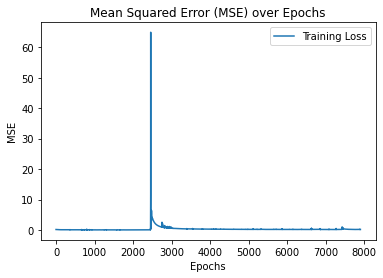

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.12491310928357324
R^2: -0.0026563511592612166
1/1 [==============================] - 0s 20ms/step


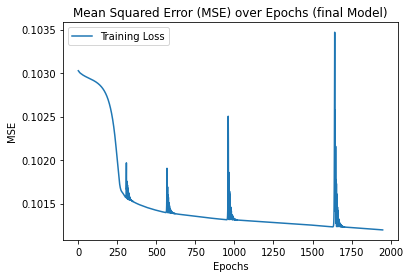

2/2 [==============================] - 0s 0s/step
Elapsed time:  13.139362699934281

HF Model:
Test MSE: 0.11596240648328102
R^2: -0.024413861328162367
2/2 [==============================] - 0s 0s/step


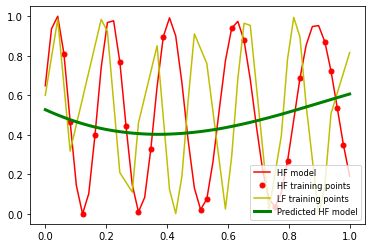

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 20  ********************
********************  # NLF: = 30  ********************


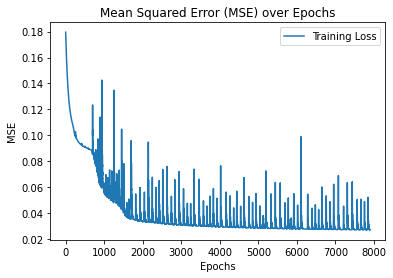

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.22404552369411848
R^2: -0.969429752703415
1/1 [==============================] - 0s 14ms/step


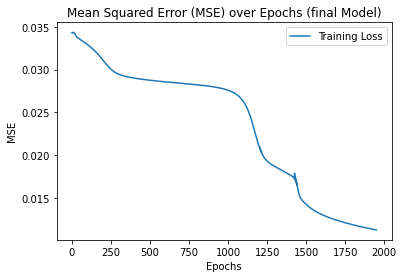

2/2 [==============================] - 0s 0s/step
Elapsed time:  13.292961099999957

HF Model:
Test MSE: 0.15310172737604527
R^2: -0.35250325061095245
2/2 [==============================] - 0s 0s/step


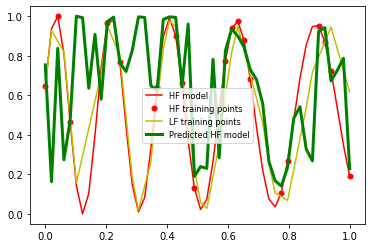

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 20  ********************
********************  # NLF: = 30  ********************


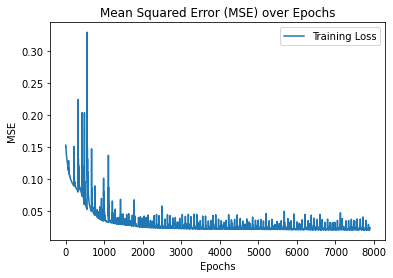

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.131367879418905
R^2: -0.11528894740464968
1/1 [==============================] - 0s 16ms/step


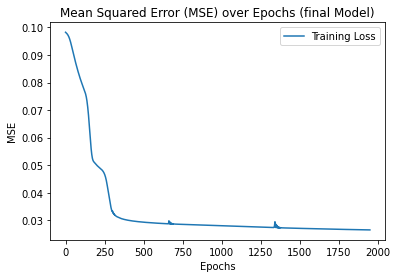

2/2 [==============================] - 0s 3ms/step
Elapsed time:  13.423123700078577

HF Model:
Test MSE: 0.08972567688104767
R^2: 0.2073618519873578
2/2 [==============================] - 0s 16ms/step


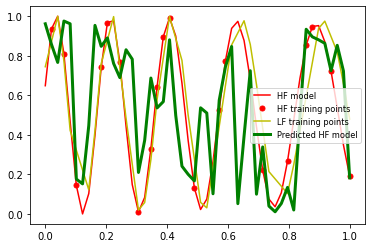

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 20  ********************
********************  # NLF: = 30  ********************


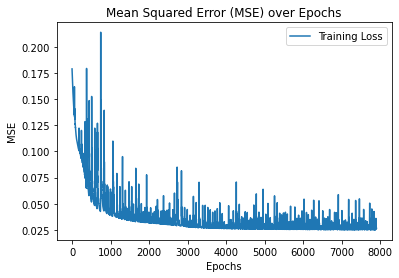

2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.2339223542793019
R^2: -1.0208411483001725
1/1 [==============================] - 0s 19ms/step


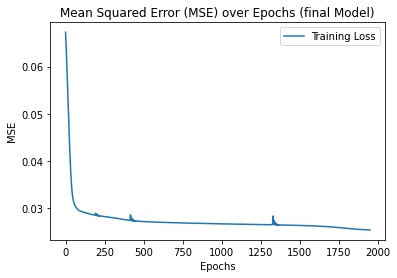

2/2 [==============================] - 0s 0s/step
Elapsed time:  13.526629099971615

HF Model:
Test MSE: 0.08905064429693409
R^2: 0.21332510125912785
2/2 [==============================] - 0s 16ms/step


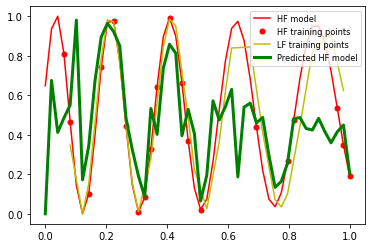

   Discretization  diffusion       R2
0            46.0        0.0 -0.02441
1            46.0        5.0 -0.35250
2            46.0       75.0  0.20736
3            46.0        1.0  0.21333
   Discretization  diffusion      MSE
0            46.0        0.0  0.11596
1            46.0        5.0  0.15310
2            46.0       75.0  0.08973
3            46.0        1.0  0.08905


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:221: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:223: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:225: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_21008\4292349223.py:227: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(

In [7]:
Discretizations=[46]
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                ### IMPORT LF DATASETs
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
                reaction_HF = reaction_HF_test[permutation][0:nhf]
                U_HF = U_HF_test[permutation][0:nhf]
                #print(nhf)

                
                reaction_LF_test = normalization(reaction_LF_test)
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                
                # randomization
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]

                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )

                test_mse_HF_list = []
                test_mse_LF_list = []

                r2_HF_list = []
                r2_LF_list = []
                
                ##########################       FIRST NN: NN_LF     ##########################
                K.clear_session()
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                
                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #

                
                modelLF = getModel(bestLF_params, "LF")  # ann_functions
                histLF = modelLF.fit(
                    reaction_LF, U_train_LF,epochs=NepoLF, batch_size=nlf, verbose=0)
                
                plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()

                ULF = modelLF.predict(reaction_LF_test)

                U_LF_list.append(ULF)
                print("\nLF Model:")
                
                test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
                test_mse_LF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
                    np.square(U_LF_test - np.mean(U_LF_test))
                )
                r2_LF_list.append(r_2)
                print(f"R^2: {r_2}")
                
                start = perf_counter()
                reaction_test_help = modelLF.predict(np.c_[reaction_HF_test,np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))])[:, 0]
                reaction_test_in = np.vstack(
                    (reaction_HF_test[:, 0], reaction_test_help)
                ).transpose()  # <- TEST INPUT for the second NN: NN_HF

                reaction_train_help = modelLF.predict(np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0]-5*np.pi/6))])[
                    :, 0
                ]  # f_LF(mu_hf_train)
                reaction_final = np.vstack(
                    (reaction_HF[:, 0], reaction_train_help)
                ).transpose()  # <- TRAINING INPUT for the second NN: NN_HF

                name = "2step"
                K.clear_session()
                # best parameters obtained by HPO:

                best_params = {
                    "kernel_init": "uniform",
                    "l2weight": 0.0002588943618918075,
                    "lr": 0.008365144388542751,
                    "nodes": 16.0,
                    "opt": "Adam",
                }
                
                # reproducibilty porpuse 
                learning_rate = best_params["lr"]
                optimizer_type = best_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                #
                
                
                
                finalModel = getModel(
                    best_params, name
                )  # final model chosen according to the best paramters
                hist = finalModel.fit(
                    reaction_final,
                    U_HF,
                    validation_data=(reaction_test_in, U_HF_test),
                    epochs=NepoHF,
                    batch_size=nhf,
                    verbose=0,
                    validation_freq=20,
                )
                plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
                plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
                plt.xlabel('Epochs')
                plt.ylabel('MSE')
                plt.legend()
                plt.show()

                UHF = finalModel.predict(reaction_test_in)
                U_HF_list.append(UHF)

                stop = perf_counter()
                elapsed = stop - start
                print("Elapsed time: ", elapsed)
                print("\nHF Model:")

                test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
                test_mse_HF_list.append(test_mse)
                print(f"Test MSE: {test_mse}")

                r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
                    np.square(U_HF_test - np.mean(U_HF_test))
                )
                r2_HF_list.append(r2_HF)
                print(f"R^2: {r2_HF}")
                
                plt.figure()
                plt.plot(
                reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                reaction_final[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_test_in[:, 0],
                finalModel.predict(reaction_test_in),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()

                #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
                #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
                #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
                #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
                
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df=r2_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df=r2_HF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df=mse_LF_df.append(new, ignore_index=True)
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df=mse_HF_df.append(new, ignore_index=True)
                
                if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
                    save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [8]:
os.makedirs("MF_LF_30_8000_HF_20_2000_2NN")

r2_HF_df.to_csv(
    "./MF_LF_30_8000_HF_20_2000_2NN/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_8000_HF_20_2000_2NN/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_8000_HF_20_2000_2NN/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_8000_HF_20_2000_2NN/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_8000_HF_20_2000_2NN/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_8000_HF_20_2000_2NN/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)